#### PyCaret Classification Example

In [1]:
# Check version
from pycaret.utils import version
version()

'3.3.2'

#### Data Repo

In [2]:
from pycaret.datasets import get_data
index = get_data('index')


,Dataset,Data Types,Default Task,Target Variable 1,Target Variable 2,# Instances,# Attributes,Missing Values
0,anomaly,Multivariate,Anomaly Detection,NaN,NaN,1000,10,N
1,france,Multivariate,Association Rule Mining,InvoiceNo,Description,8557,8,N
2,germany,Multivariate,Association Rule Mining,InvoiceNo,Description,9495,8,N
3,bank,Multivariate,Classification (Binary),deposit,NaN,45211,17,N
4,blood,Multivariate,Classification (Binary),Class,NaN,748,5,N
5,cancer,Multivariate,Classification (Binary),Class,NaN,683,10,N
6,credit,Multivariate,Classification (Binary),default,NaN,24000,24,N
7,diabetes,Multivariate,Classification (Binary),Class variable,NaN,768,9,N
8,electrical_grid,Multivariate,Classification (Binary),stabf,NaN,10000,14,N
9,employee,Multivariate,Classification (Binary),left,NaN,14999,10,N


In [3]:
# data = get_data('traffic')
data = get_data('juice')


,Id,Purchase,WeekofPurchase,StoreID,PriceCH,PriceMM,DiscCH,DiscMM,SpecialCH,SpecialMM,LoyalCH,SalePriceMM,SalePriceCH,PriceDiff,Store7,PctDiscMM,PctDiscCH,ListPriceDiff,STORE
0,1,CH,237,1,1.75,1.99,0.00,0.0,0,0,0.500000,1.99,1.75,0.24,No,0.000000,0.000000,0.24,1
1,2,CH,239,1,1.75,1.99,0.00,0.3,0,1,0.600000,1.69,1.75,-0.06,No,0.150754,0.000000,0.24,1
2,3,CH,245,1,1.86,2.09,0.17,0.0,0,0,0.680000,2.09,1.69,0.40,No,0.000000,0.091398,0.23,1
3,4,MM,227,1,1.69,1.69,0.00,0.0,0,0,0.400000,1.69,1.69,0.00,No,0.000000,0.000000,0.00,1
4,5,CH,228,7,1.69,1.69,0.00,0.0,0,0,0.956535,1.69,1.69,0.00,Yes,0.000000,0.000000,0.00,0


### Initial Setup

In [4]:
from pycaret.classification import *
clf1 = setup(data, target = 'Purchase', session_id=123, log_experiment=False, experiment_name='juice1')

,Description,Value
0,Session id,123
1,Target,Purchase
2,Target type,Binary
3,Target mapping,"CH: 0, MM: 1"
4,Original data shape,"(1070, 19)"
5,Transformed data shape,"(1070, 19)"
6,Transformed train set shape,"(749, 19)"
7,Transformed test set shape,"(321, 19)"
8,Numeric features,17
9,Categorical features,1


#### Compare baseline

In [5]:
best_model = compare_models()

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lda,Linear Discriminant Analysis,0.8278,0.8941,0.8278,0.8299,0.8268,0.6354,0.6388,0.2180
lr,Logistic Regression,0.8171,0.8930,0.8171,0.8184,0.8148,0.6090,0.6134,7.4800
ridge,Ridge Classifier,0.8158,0.8938,0.8158,0.8183,0.8146,0.6099,0.6138,0.1660
gbc,Gradient Boosting Classifier,0.8037,0.8888,0.8037,0.8086,0.8031,0.5877,0.5926,0.6470
catboost,CatBoost Classifier,0.7944,0.8889,0.7944,0.7960,0.7931,0.5643,0.5676,5.9660
lightgbm,Light Gradient Boosting Machine,0.7930,0.8729,0.7930,0.7946,0.7925,0.5636,0.5658,0.3640
ada,Ada Boost Classifier,0.7917,0.8640,0.7917,0.7917,0.7899,0.5565,0.5592,0.5020
xgboost,Extreme Gradient Boosting,0.7878,0.8623,0.7878,0.7884,0.7870,0.5517,0.5534,0.4140
rf,Random Forest Classifier,0.7797,0.8724,0.7797,0.7819,0.7789,0.5355,0.5384,0.8880
et,Extra Trees Classifier,0.7678,0.8479,0.7678,0.7685,0.7669,0.5097,0.5114,0.7370


#### Create Model

In [6]:
lr = create_model('lr')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.7867,0.8546,0.7867,0.7952,0.7887,0.5614,0.5648
1,0.8400,0.9183,0.8400,0.8434,0.8357,0.6493,0.6595
2,0.8267,0.8943,0.8267,0.8280,0.8272,0.6369,0.6371
3,0.7333,0.8313,0.7333,0.7305,0.7227,0.4076,0.4195
4,0.7600,0.8508,0.7600,0.7600,0.7600,0.4940,0.4940
5,0.8133,0.8988,0.8133,0.8123,0.8103,0.5962,0.6002
6,0.8667,0.9400,0.8667,0.8667,0.8667,0.7189,0.7189
7,0.8400,0.9193,0.8400,0.8441,0.8361,0.6552,0.6651
8,0.8800,0.9356,0.8800,0.8806,0.8788,0.7458,0.7485


In [7]:
dt = create_model('dt')

In [8]:
rf = create_model('rf', fold=5)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.7667,0.8630,0.7667,0.7638,0.7623,0.4935,0.4978
1,0.7400,0.8267,0.7400,0.7428,0.7411,0.4570,0.4574
2,0.7733,0.8759,0.7733,0.7749,0.7740,0.5279,0.5281
3,0.7800,0.8738,0.7800,0.7807,0.7803,0.5404,0.5404
4,0.8255,0.8933,0.8255,0.8243,0.8243,0.6284,0.6294
Mean,0.7771,0.8666,0.7771,0.7773,0.7764,0.5294,0.5306
Std,0.0278,0.0222,0.0278,0.0268,0.0274,0.0573,0.0571


In [9]:
lda = create_model('lda')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8133,0.8516,0.8133,0.8215,0.8151,0.6162,0.6200
1,0.8267,0.9123,0.8267,0.8273,0.8230,0.6225,0.6292
2,0.8533,0.8898,0.8533,0.8584,0.8545,0.6966,0.6990
3,0.7467,0.8343,0.7467,0.7429,0.7412,0.4483,0.4531
4,0.7600,0.8651,0.7600,0.7638,0.7613,0.5004,0.5011
5,0.8267,0.8988,0.8267,0.8258,0.8261,0.6322,0.6325
6,0.8800,0.9483,0.8800,0.8847,0.8809,0.7517,0.7543
7,0.8400,0.9200,0.8400,0.8441,0.8361,0.6552,0.6651
8,0.8800,0.9363,0.8800,0.8796,0.8796,0.7486,0.7489


In [10]:
models()

,Name,Reference,Turbo
ID,,,
lr,Logistic Regression,sklearn.linear_model._logistic.LogisticRegression,True
knn,K Neighbors Classifier,sklearn.neighbors._classification.KNeighborsCl...,True
nb,Naive Bayes,sklearn.naive_bayes.GaussianNB,True
dt,Decision Tree Classifier,sklearn.tree._classes.DecisionTreeClassifier,True
svm,SVM - Linear Kernel,sklearn.linear_model._stochastic_gradient.SGDC...,True
rbfsvm,SVM - Radial Kernel,sklearn.svm._classes.SVC,False
gpc,Gaussian Process Classifier,sklearn.gaussian_process._gpc.GaussianProcessC...,False
mlp,MLP Classifier,sklearn.neural_network._multilayer_perceptron....,False
ridge,Ridge Classifier,sklearn.linear_model._ridge.RidgeClassifier,True


In [11]:
models(type='ensemble').index.tolist()

['rf', 'ada', 'gbc', 'et', 'xgboost', 'lightgbm', 'catboost']

In [12]:
ensembled_models = compare_models(include = models(type='ensemble').index.tolist(), fold = 3)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
gbc,Gradient Boosting Classifier,0.8051,0.8783,0.8051,0.8046,0.8047,0.5888,0.5891,0.6300
catboost,CatBoost Classifier,0.7958,0.8815,0.7958,0.7951,0.7952,0.5685,0.5689,5.9300
xgboost,Extreme Gradient Boosting,0.7904,0.8595,0.7904,0.7919,0.7909,0.5618,0.5621,0.3000
lightgbm,Light Gradient Boosting Machine,0.7891,0.8696,0.7891,0.7890,0.7889,0.5561,0.5563,0.7767
rf,Random Forest Classifier,0.7878,0.8685,0.7878,0.7866,0.7870,0.5508,0.5511,1.0333
ada,Ada Boost Classifier,0.7851,0.8565,0.7851,0.7846,0.7846,0.5466,0.5469,0.7400
et,Extra Trees Classifier,0.7704,0.8440,0.7704,0.7694,0.7694,0.5138,0.5146,1.0100


##### Hyper Parameter Tunning

In [13]:
# tuned logistic regression
tuned_lr = tune_model(lr)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.7733,0.8546,0.7733,0.8014,0.7763,0.5480,0.5644
1,0.8267,0.9190,0.8267,0.8255,0.8247,0.6274,0.6298
2,0.8000,0.8943,0.8000,0.8189,0.8025,0.5963,0.6072
3,0.8133,0.8351,0.8133,0.8133,0.8133,0.6064,0.6064
4,0.7467,0.8486,0.7467,0.7849,0.7497,0.5009,0.5232
5,0.8267,0.9018,0.8267,0.8280,0.8272,0.6369,0.6371
6,0.8800,0.9400,0.8800,0.8905,0.8813,0.7548,0.7619
7,0.8667,0.9178,0.8667,0.8663,0.8658,0.7191,0.7202
8,0.8667,0.9356,0.8667,0.8667,0.8667,0.7222,0.7222


Fitting 10 folds for each of 10 candidates, totalling 100 fits


In [14]:
# tuned random forest
tuned_rf = tune_model(rf)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.7733,0.8508,0.7733,0.7851,0.7758,0.5369,0.5419
1,0.8667,0.9280,0.8667,0.8667,0.8667,0.7189,0.7189
2,0.7867,0.8741,0.7867,0.8100,0.7894,0.5720,0.5856
3,0.7600,0.8246,0.7600,0.7638,0.7613,0.5004,0.5011
4,0.7867,0.8658,0.7867,0.8100,0.7894,0.5720,0.5856
5,0.8267,0.9168,0.8267,0.8280,0.8272,0.6369,0.6371
6,0.8133,0.9055,0.8133,0.8282,0.8156,0.6209,0.6293
7,0.8133,0.8978,0.8133,0.8163,0.8142,0.6154,0.6163
8,0.8400,0.9193,0.8400,0.8427,0.8408,0.6703,0.6713


Fitting 10 folds for each of 10 candidates, totalling 100 fits


#### Ensemble Models

In [15]:
bagged_dt = ensemble_model(dt, method='Bagging')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.7733,0.8107,0.7733,0.7793,0.7751,0.5311,0.5329
1,0.8267,0.8868,0.8267,0.8273,0.8230,0.6225,0.6292
2,0.7733,0.8231,0.7733,0.7721,0.7726,0.5190,0.5193
3,0.7067,0.7594,0.7067,0.7067,0.7067,0.3816,0.3816
4,0.7733,0.8699,0.7733,0.7721,0.7726,0.5190,0.5193
5,0.8533,0.9112,0.8533,0.8527,0.8528,0.6888,0.6891
6,0.8000,0.8969,0.8000,0.8057,0.8015,0.5862,0.5883
7,0.8133,0.8585,0.8133,0.8129,0.8106,0.6023,0.6062
8,0.7867,0.9200,0.7867,0.7873,0.7815,0.5402,0.5484


In [16]:
boosted_dt = ensemble_model(dt, method= 'Boosting')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.7600,0.7725,0.7600,0.7834,0.7631,0.5185,0.5308
1,0.8000,0.7924,0.8000,0.8015,0.8006,0.5810,0.5812
2,0.7467,0.7361,0.7467,0.7484,0.7474,0.4693,0.4695
3,0.6800,0.6627,0.6800,0.6800,0.6800,0.3253,0.3253
4,0.7333,0.7253,0.7333,0.7373,0.7348,0.4449,0.4455
5,0.7733,0.7642,0.7733,0.7750,0.7740,0.5251,0.5253
6,0.8267,0.8205,0.8267,0.8280,0.8272,0.6369,0.6371
7,0.7333,0.7222,0.7333,0.7333,0.7333,0.4444,0.4444
8,0.8133,0.8111,0.8133,0.8163,0.8142,0.6154,0.6163


##### Blend Models

In [17]:
blender = blend_models(estimator_list = [boosted_dt, bagged_dt, tuned_rf], method='soft')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.7600,0.8441,0.7600,0.7834,0.7631,0.5185,0.5308
1,0.8267,0.9190,0.8267,0.8258,0.8261,0.6322,0.6325
2,0.7467,0.8471,0.7467,0.7484,0.7474,0.4693,0.4695
3,0.7067,0.7744,0.7067,0.7035,0.7045,0.3736,0.3742
4,0.7333,0.8696,0.7333,0.7426,0.7359,0.4518,0.4545
5,0.8400,0.8996,0.8400,0.8430,0.8409,0.6669,0.6679
6,0.8000,0.9198,0.8000,0.8057,0.8015,0.5862,0.5883
7,0.7600,0.8615,0.7600,0.7600,0.7600,0.5000,0.5000
8,0.8267,0.9230,0.8267,0.8316,0.8278,0.6448,0.6470


#### Stack Models

In [18]:
stacker = stack_models(estimator_list = [boosted_dt, bagged_dt, tuned_rf], meta_model=rf)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.7467,0.8396,0.7467,0.7452,0.7458,0.4625,0.4627
1,0.7733,0.8568,0.7733,0.7707,0.7707,0.5128,0.5147
2,0.7200,0.8111,0.7200,0.7219,0.7208,0.4134,0.4136
3,0.7333,0.8137,0.7333,0.7333,0.7333,0.4378,0.4378
4,0.7067,0.7942,0.7067,0.7162,0.7095,0.3969,0.3993
5,0.8133,0.8699,0.8133,0.8133,0.8133,0.6064,0.6064
6,0.7600,0.8939,0.7600,0.7577,0.7583,0.4875,0.4883
7,0.7067,0.8181,0.7067,0.7067,0.7067,0.3889,0.3889
8,0.7733,0.8841,0.7733,0.7713,0.7710,0.5198,0.5217


#### Analyze Model

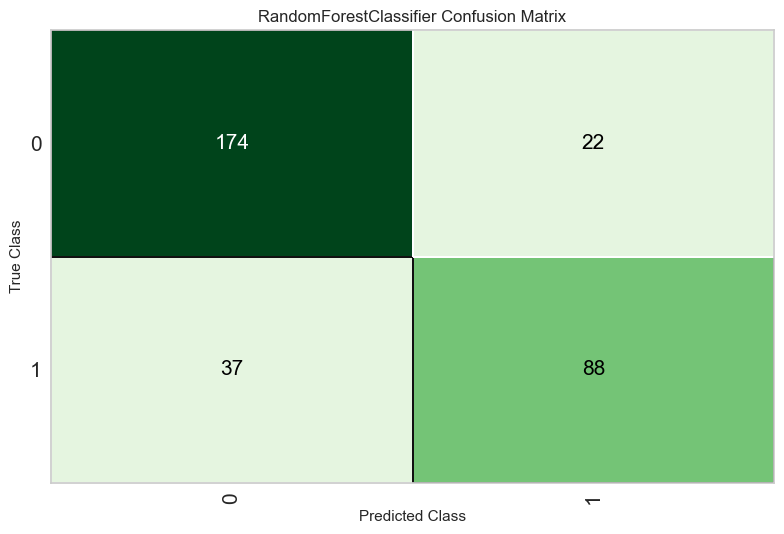

In [19]:
plot_model(rf, plot= 'confusion_matrix')

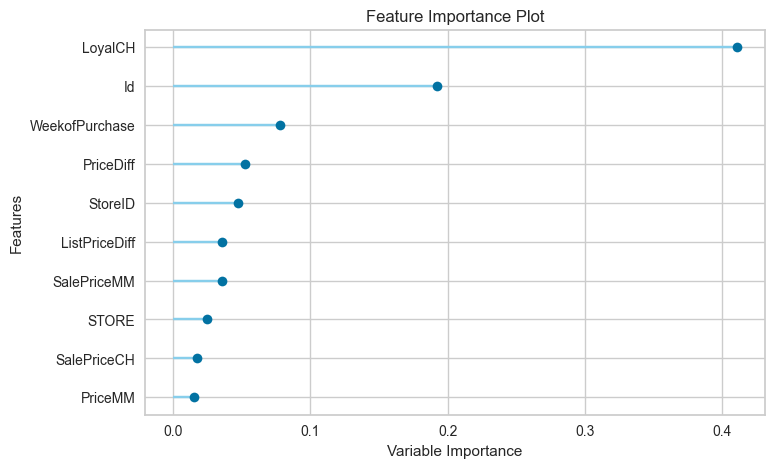

In [20]:
plot_model(rf, plot= 'feature')

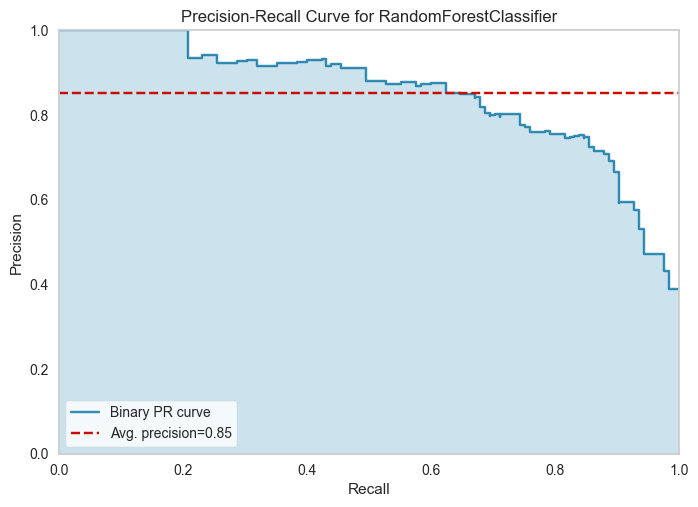

In [21]:
plot_model(rf, plot= 'pr')

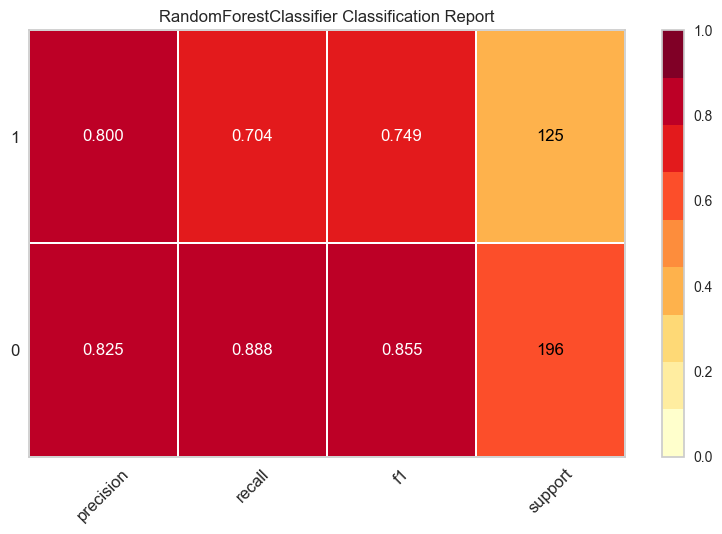

In [22]:
plot_model(rf, plot= 'class_report')

In [23]:
evaluate_model(rf)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

##### Interpret Model

In [24]:
catboost = create_model('catboost', cross_validation=False)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Test,0.8411,0.8945,0.8411,0.8401,0.8399,0.6615,0.6627


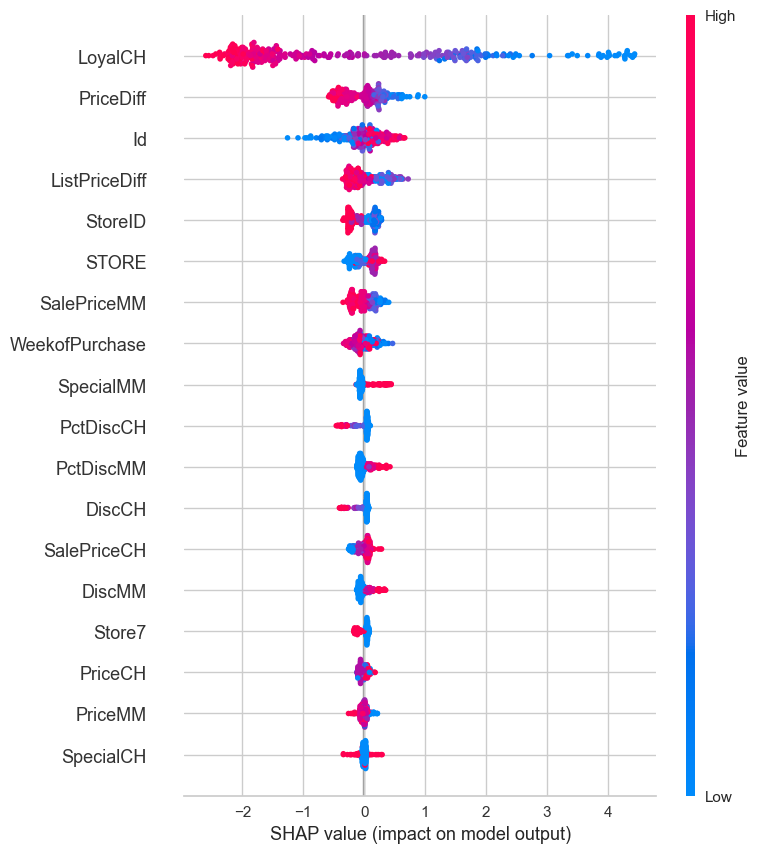

In [25]:
interpret_model(catboost)

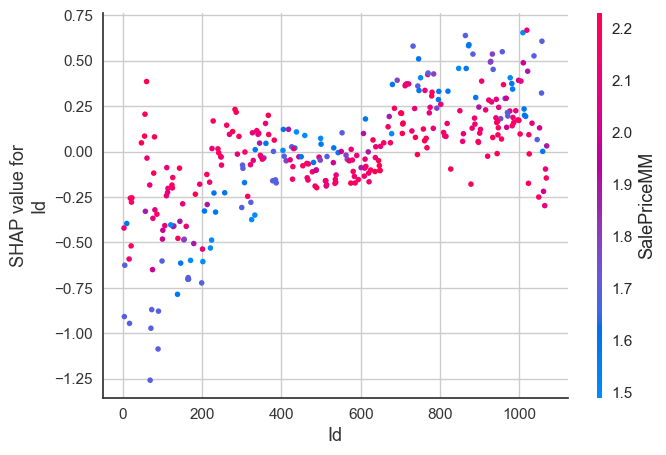

In [26]:
interpret_model(catboost, plot = 'correlation')

#### Auto ML

In [27]:
best = automl(optimize = 'Recall')

#### Predict Model

In [28]:
pred_holdout = predict_model(best)
pred_holdout.head()

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Linear Discriminant Analysis,0.8380,0.9073,0.8380,0.8371,0.8372,0.6564,0.6569


,Id,WeekofPurchase,StoreID,PriceCH,PriceMM,DiscCH,DiscMM,SpecialCH,SpecialMM,LoyalCH,...,SalePriceCH,PriceDiff,Store7,PctDiscMM,PctDiscCH,ListPriceDiff,STORE,Purchase,prediction_label,prediction_score
1065,1066,252,7,1.86,2.09,0.10,0.0,0,0,0.587822,...,1.76,0.33,Yes,0.000000,0.053763,0.23,0,CH,CH,0.8574
745,746,233,7,1.75,1.99,0.00,0.4,1,0,0.500000,...,1.75,-0.16,Yes,0.201005,0.000000,0.24,0,CH,MM,0.5164
562,563,230,4,1.79,1.79,0.00,0.0,0,0,0.667200,...,1.79,0.00,No,0.000000,0.000000,0.00,4,CH,CH,0.6695
333,334,236,7,1.75,1.99,0.00,0.4,0,0,0.119538,...,1.75,-0.16,Yes,0.201005,0.000000,0.24,0,MM,MM,0.8869
477,478,266,7,1.86,2.13,0.37,0.0,1,0,0.616000,...,1.49,0.64,Yes,0.000000,0.198925,0.27,0,CH,CH,0.9520


In [29]:
new_data = data.copy()
new_data.drop(['Purchase'], axis=1, inplace=True)
predict_new = predict_model(best, data=new_data)
predict_new.head()

,Id,WeekofPurchase,StoreID,PriceCH,PriceMM,DiscCH,DiscMM,SpecialCH,SpecialMM,LoyalCH,SalePriceMM,SalePriceCH,PriceDiff,Store7,PctDiscMM,PctDiscCH,ListPriceDiff,STORE,prediction_label,prediction_score
0,1,237,1,1.75,1.99,0.00,0.0,0,0,0.500000,1.99,1.75,0.24,No,0.000000,0.000000,0.24,1,CH,0.6296
1,2,239,1,1.75,1.99,0.00,0.3,0,1,0.600000,1.69,1.75,-0.06,No,0.150754,0.000000,0.24,1,CH,0.6131
2,3,245,1,1.86,2.09,0.17,0.0,0,0,0.680000,2.09,1.69,0.40,No,0.000000,0.091398,0.23,1,CH,0.9264
3,4,227,1,1.69,1.69,0.00,0.0,0,0,0.400000,1.69,1.69,0.00,No,0.000000,0.000000,0.00,1,MM,0.7843
4,5,228,7,1.69,1.69,0.00,0.0,0,0,0.956535,1.69,1.69,0.00,Yes,0.000000,0.000000,0.00,0,CH,0.9604


### Save model

In [36]:
save_model(best, model_name='./saved_models/pycaret_best_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('label_encoding',
                  TransformerWrapperWithInverse(exclude=None, include=None,
                                                transformer=LabelEncoder())),
                 ('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['Id', 'WeekofPurchase', 'StoreID',
                                              'PriceCH', 'PriceMM', 'DiscCH',
                                              'DiscMM', 'SpecialCH', 'SpecialMM',
                                              'LoyalCH', 'SalePriceMM',
                                              'SalePriceCH', 'PriceDi...
                                                                drop_invariant=False,
                                                                handle_missing='return_nan',
                                                                handle_unknown='value',
                           

In [ ]:
loaded_best_model = load_model('./saved_models/pycaret_best_model')
predict_model(loaded_best_model)

Transformation Pipeline and Model Successfully Loaded


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Linear Discriminant Analysis,0.8380,0.9073,0.8380,0.8371,0.8372,0.6564,0.6569


,Id,WeekofPurchase,StoreID,PriceCH,PriceMM,DiscCH,DiscMM,SpecialCH,SpecialMM,LoyalCH,...,SalePriceCH,PriceDiff,Store7,PctDiscMM,PctDiscCH,ListPriceDiff,STORE,Purchase,prediction_label,prediction_score
1065,1066,252,7,1.86,2.09,0.10,0.0,0,0,0.587822,...,1.76,0.33,Yes,0.000000,0.053763,0.23,0,CH,CH,0.8574
745,746,233,7,1.75,1.99,0.00,0.4,1,0,0.500000,...,1.75,-0.16,Yes,0.201005,0.000000,0.24,0,CH,MM,0.5164
562,563,230,4,1.79,1.79,0.00,0.0,0,0,0.667200,...,1.79,0.00,No,0.000000,0.000000,0.00,4,CH,CH,0.6695
333,334,236,7,1.75,1.99,0.00,0.4,0,0,0.119538,...,1.75,-0.16,Yes,0.201005,0.000000,0.24,0,MM,MM,0.8869
477,478,266,7,1.86,2.13,0.37,0.0,1,0,0.616000,...,1.49,0.64,Yes,0.000000,0.198925,0.27,0,CH,CH,0.9520
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
163,164,271,4,1.99,2.09,0.10,0.4,1,0,0.985926,...,1.89,-0.20,No,0.191388,0.050251,0.10,4,CH,CH,0.9353
75,76,238,4,1.79,2.09,0.00,0.0,0,0,0.744000,...,1.79,0.30,No,0.000000,0.000000,0.30,4,CH,CH,0.9400
927,928,231,3,1.79,1.79,0.00,0.0,0,0,0.256000,...,1.79,0.00,No,0.000000,0.000000,0.00,3,MM,MM,0.9184
453,454,268,2,1.86,2.18,0.00,0.0,0,1,0.587983,...,1.86,0.32,No,0.000000,0.000000,0.32,2,CH,CH,0.7458


In [34]:
from sklearn import set_config
set_config(display='diagram')
loaded_best_model

Pipeline(memory=FastMemory(location=C:\Users\ITLOGI~1\AppData\Local\Temp\joblib),
         steps=[('label_encoding',
                 TransformerWrapperWithInverse(exclude=None, include=None,
                                               transformer=LabelEncoder())),
                ('numerical_imputer',
                 TransformerWrapper(exclude=None,
                                    include=['Id', 'WeekofPurchase', 'StoreID',
                                             'PriceCH', 'PriceMM', 'DiscCH',
                                             'DiscMM', 'SpecialCH', 'SpecialMM',
                                             'Lo...
                                                               drop_invariant=False,
                                                               handle_missing='return_nan',
                                                               handle_unknown='value',
                                                               mapping=[{'col': 'Store7',
                                                                         'data_type': dtype('O'),
                                                                         'mapping': No     0
Yes    1
NaN   -1
dtype: int64}],
                                                               return_df=True,
                                                               verbose=0))),
                ('trained_model',
                 LinearDiscriminantAnalysis(covariance_estimator=None,
                                            n_components=None, priors=None,
                                            shrinkage=None, solver='svd',
                                            store_covariance=False,
                                            tol=0.0001))],
         verbose=False)

#### Deploy Model

In [35]:
deploy_model(best, model_name="best_aws", authentication={'bucket': 'pycaret_test'})

ValueError: Boto3 credentials not configured. Refer boto3 documentation (https://boto3.amazonaws.com/v1/documentation/api/latest/guide/credentials.html)

#### Configs

In [ ]:
X_train = get_config('X_train')
X_train.head()

In [ ]:
!pip install mlflow ui